# EDA — Dataset de objetos: `curated_axis_sym_obj` / `curated_plane_sym_obj`

Análisis exploratorio del dataset de entrada: 850 mallas 3D con simetría axial
y 850 con simetría planar (ShapeNet, normalizadas), junto con sus etiquetas ground-truth.

**Preguntas guía:**
- ¿Qué tan compleja y variable es la geometría de las mallas?
- ¿Qué estructura tienen las etiquetas de simetría (dirección, orden, número de planos)?
- ¿Qué sesgos hereda el dataset de la pose canónica de ShapeNet?
- ¿Existen inconsistencias de normalización entre los dos curated sets?


In [26]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# ── Estilo académico unificado ────────────────────────────────────────────
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

mpl.rcParams.update({
    'font.family'           : 'DejaVu Sans',
    'font.size'             : 10,
    'axes.titlesize'        : 11,
    'axes.titleweight'      : 'bold',
    'axes.labelsize'        : 10,
    'xtick.labelsize'       : 9,
    'ytick.labelsize'       : 9,
    'legend.fontsize'       : 9,
    'legend.framealpha'     : 0.92,
    'legend.edgecolor'      : '#cccccc',
    'legend.borderpad'      : 0.6,
    'axes.spines.top'       : False,
    'axes.spines.right'     : False,
    'axes.grid'             : True,
    'grid.alpha'            : 0.35,
    'grid.linewidth'        : 0.6,
    'grid.color'            : '#cccccc',
    'lines.linewidth'       : 1.8,
    'patch.linewidth'       : 0.5,
    'figure.constrained_layout.use': True,
})

# ── Paleta de colores (distinguible en escala de grises y para daltonismo) ─
C_AXIS   = '#2166ac'   # azul        – axis_sym
C_PLANE  = '#d6604d'   # rojo-naranja – plane_sym
C_X      = '#b2182b'   # rojo        – eje canónico X
C_Y      = '#1a9641'   # verde       – eje canónico Y
C_Z      = '#4393c3'   # celeste     – eje canónico Z
C_PURPLE = '#762a83'

AXIS_DIR  = Path("../../data/objects/curated_axis_sym_obj")
PLANE_DIR = Path("../../data/objects/curated_plane_sym_obj")

for d in (AXIS_DIR, PLANE_DIR):
    if not d.exists():
        raise FileNotFoundError(f"Carpeta no encontrada: {d.resolve()}")

print(f"AXIS_DIR  -> {AXIS_DIR.resolve()}")
print(f"PLANE_DIR -> {PLANE_DIR.resolve()}")


AXIS_DIR  -> C:\Users\HP\Desktop\Seminario de Tesis I\data\objects\curated_axis_sym_obj
PLANE_DIR -> C:\Users\HP\Desktop\Seminario de Tesis I\data\objects\curated_plane_sym_obj


## 1. Integridad: pares OBJ/TXT


In [27]:
def check_pairs(obj_dir: Path, label: str) -> pd.DataFrame:
    obj_ids = {p.stem for p in obj_dir.glob('*.obj')}
    txt_ids = {p.stem for p in obj_dir.glob('*.txt')}
    all_ids = sorted(obj_ids | txt_ids)
    df = pd.DataFrame([{
        'object_id': oid, 'has_obj': oid in obj_ids, 'has_txt': oid in txt_ids,
    } for oid in all_ids])
    df['symmetry_type'] = label
    n_obj, n_txt = (~df['has_obj']).sum(), (~df['has_txt']).sum()
    print(f"[{label}]  .obj={len(obj_ids)}  .txt={len(txt_ids)}  "
          f"faltan_obj={n_obj}  faltan_txt={n_txt}")
    return df

df_axis_pairs  = check_pairs(AXIS_DIR,  'axis_sym')
df_plane_pairs = check_pairs(PLANE_DIR, 'plane_sym')

assert (df_axis_pairs['has_obj']  & df_axis_pairs['has_txt']).all()
assert (df_plane_pairs['has_obj'] & df_plane_pairs['has_txt']).all()
print("\nDataset completo: cada .obj tiene su .txt en ambos sets.")


[axis_sym]  .obj=850  .txt=850  faltan_obj=0  faltan_txt=0
[plane_sym]  .obj=850  .txt=850  faltan_obj=0  faltan_txt=0

Dataset completo: cada .obj tiene su .txt en ambos sets.


## 2. Parsers de etiquetas

Formato de los archivos `.txt`:

```
# axis_sym                                  # plane_sym (1–3 planos)
1                                           2
axis DX DY DZ  OX OY OZ                    plane NX NY NZ  OX OY OZ
4                                           plane NX NY NZ  OX OY OZ
angles 180 36 72 90
```

Para `axis_sym`, la sección `angles` lista los ángulos (grados) bajo los que el objeto es
simétrico al rotar alrededor del eje. Derivamos el orden rotacional como `n = round(360 / θ)`.


In [28]:
def parse_axis_label(txt_path: Path) -> dict:
    lines = [l.strip() for l in txt_path.read_text(encoding='utf-8', errors='ignore').splitlines() if l.strip()]
    parts = lines[1].split()[1:]
    direction = tuple(float(x) for x in parts[:3])
    origin    = tuple(float(x) for x in parts[3:6])
    n_angles  = int(lines[2])
    angles    = [float(x) for x in lines[3].split()[1:]]
    return {'direction': direction, 'origin': origin, 'n_angles': n_angles, 'angles': angles}


def parse_plane_label(txt_path: Path) -> dict:
    lines = [l.strip() for l in txt_path.read_text(encoding='utf-8', errors='ignore').splitlines() if l.strip()]
    n_planes = int(lines[0])
    planes = []
    for line in lines[1:1 + n_planes]:
        parts = line.split()[1:]
        planes.append({'normal': tuple(float(x) for x in parts[:3]),
                       'origin': tuple(float(x) for x in parts[3:6])})
    return {'n_planes': n_planes, 'planes': planes}


def mesh_stats(obj_path: Path) -> dict:
    n_v = n_f = 0
    mins = np.full(3,  np.inf)
    maxs = np.full(3, -np.inf)
    with obj_path.open('r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            if line.startswith('v '):
                n_v += 1
                xyz = np.array([float(p) for p in line.split()[1:4]])
                mins = np.minimum(mins, xyz)
                maxs = np.maximum(maxs, xyz)
            elif line.startswith('f '):
                n_f += 1
    extent = maxs - mins
    return {'vertex_count': n_v, 'face_count': n_f,
            'bbox_extent': tuple(extent),
            'bbox_diag': float(np.linalg.norm(extent)) if n_v else np.nan}

print("Parsers definidos.")


Parsers definidos.


## 3. Construcción de las tablas de trabajo


In [29]:
def build_axis_df(obj_dir: Path) -> pd.DataFrame:
    rows = []
    for txt_path in sorted(obj_dir.glob('*.txt')):
        oid = txt_path.stem
        label  = parse_axis_label(txt_path)
        mstats = mesh_stats(obj_dir / f"{oid}.obj")
        orders = [round(360.0 / a) if a > 0 else np.nan for a in label['angles']]
        rows.append({**mstats,
                     'object_id': oid, 'symmetry_type': 'axis_sym',
                     'direction': label['direction'], 'origin': label['origin'],
                     'n_angles': label['n_angles'], 'angles': label['angles'],
                     'rotation_orders': orders,
                     'max_rotation_order': max(orders) if orders else np.nan})
    return pd.DataFrame(rows)


def build_plane_df(obj_dir: Path) -> pd.DataFrame:
    rows = []
    for txt_path in sorted(obj_dir.glob('*.txt')):
        oid = txt_path.stem
        label  = parse_plane_label(txt_path)
        mstats = mesh_stats(obj_dir / f"{oid}.obj")
        rows.append({**mstats,
                     'object_id': oid, 'symmetry_type': 'plane_sym',
                     'n_planes': label['n_planes'],
                     'normals': [p['normal'] for p in label['planes']]})
    return pd.DataFrame(rows)


df_axis  = build_axis_df(AXIS_DIR)
df_plane = build_plane_df(PLANE_DIR)
df_all   = pd.concat([
    df_axis [['object_id','symmetry_type','vertex_count','face_count','bbox_diag']],
    df_plane[['object_id','symmetry_type','vertex_count','face_count','bbox_diag']],
], ignore_index=True)

print(f"df_axis : {len(df_axis)}  objetos")
print(f"df_plane: {len(df_plane)} objetos")
df_axis.head()


df_axis : 850  objetos
df_plane: 850 objetos


,vertex_count,face_count,bbox_extent,bbox_diag,object_id,symmetry_type,direction,origin,n_angles,angles,rotation_orders,max_rotation_order
0,520,552,"(0.732147, 0.752044, 0.685074)",1.253370,10433e5bd8fa2a337b00c7b93209c459,axis_sym,"(0.7571783332820677, 0.6410833153102238, 0.125...","(0.0, 0.0, 0.0)",4,"[180.0, 36.0, 72.0, 90.0]","[2, 10, 5, 4]",10
1,32000,62800,"(0.6695040000000001, 0.615833, 0.666477)",1.127687,10e72272bc46378a2c59a4d90e63212,axis_sym,"(-0.7844999760020394, 0.027979728012959552, 0....","(0.0, 0.0, 0.0)",3,"[72.0, 36.0, 180.0]","[5, 10, 2]",10
2,4524,4312,"(0.887342, 0.582451, 0.427319)",1.144214,10f709cecfbb8d59c2536abb1e8e5eab,axis_sym,"(-0.8741180186509224, -0.43041707026162795, 0....","(0.0, 0.0, 0.0)",5,"[180.0, 90.0, 45.0, 60.0, 120.0]","[2, 4, 8, 6, 3]",8
3,1344,2104,"(0.500683, 0.901449, 0.405904)",1.108175,114509277e76e413c8724d5673a063a6,axis_sym,"(0.38456063812325314, 0.880386866575199, -0.27...","(0.0, 0.0, 0.0)",5,"[60.0, 90.0, 45.0, 180.0, 120.0]","[6, 4, 8, 2, 3]",8
4,7418,6044,"(0.368664, 0.679254, 0.659931)",1.016272,11547e8d8f143557525b133235812833,axis_sym,"(0.9689123716237121, -0.04425747214430078, -0....","(0.0, 0.0, 0.0)",5,"[45.0, 180.0, 90.0, 60.0, 120.0]","[8, 2, 4, 6, 3]",8


In [30]:
df_plane.head()


,vertex_count,face_count,bbox_extent,bbox_diag,object_id,symmetry_type,n_planes,normals
0,266,1020,"(0.789337, 0.423139, 0.444859)",1.000000,10654ea604644c8eca7ed590d69b9804,plane_sym,1,"[(0.9999983279161366, 0.0015400772500103288, 0..."
1,460,1992,"(0.86395, 0.41455299999999995, 0.285899)",1.000001,1074bdcb3c2032fe0f3f8b6e1796773,plane_sym,1,"[(1.0, 0.0, 0.0)]"
2,400,1296,"(0.483508, 0.837573, 0.254345)",1.000000,109a19840a8fbc774c3aee8e9d3a6ffa,plane_sym,1,"[(0.9999999971087714, -6.283442232219851e-05, ..."
3,372,900,"(0.82564, 0.516025, 0.228117)",1.000000,10b54fe832a00c3ec59350d819542ec7,plane_sym,1,"[(0.9999999541776885, 0.0001289444664394186, 0..."
4,207,742,"(0.526543, 0.789814, 0.314558)",1.000000,10c484963692d3c87d40405e5ee68b4f,plane_sym,1,"[(0.999999999076595, 4.297758970206119e-05, -1..."


## 4. Duplicados entre datasets


In [31]:
shared = set(df_axis['object_id']) & set(df_plane['object_id'])
print(f"IDs compartidos entre curated_axis_sym_obj y curated_plane_sym_obj: {len(shared)}")


IDs compartidos entre curated_axis_sym_obj y curated_plane_sym_obj: 0


## 5. Complejidad geométrica: vértices y caras

Una malla más densa puede producir más puntos válidos en el ray-casting de `map_to_3d.py`,
lo cual podría inflar artificialmente las métricas de evaluación de Molmo2.


In [32]:
print("Estadísticas de complejidad por tipo de simetría:")
print(df_all.groupby('symmetry_type')[['vertex_count','face_count']].describe().T.round(0))


Estadísticas de complejidad por tipo de simetría:
symmetry_type       axis_sym  plane_sym
vertex_count count     850.0      850.0
             mean    12112.0     5449.0
             std     31473.0     7784.0
             min        24.0      191.0
             25%      1574.0      882.0
             50%      3834.0     2143.0
             75%     10546.0     6688.0
             max    480092.0    75563.0
face_count   count     850.0      850.0
             mean    12750.0    21150.0
             std     24770.0    30513.0
             min        16.0      712.0
             25%      1724.0     3452.0
             50%      4530.0     8382.0
             75%     13539.0    25965.0
             max    262048.0   284996.0


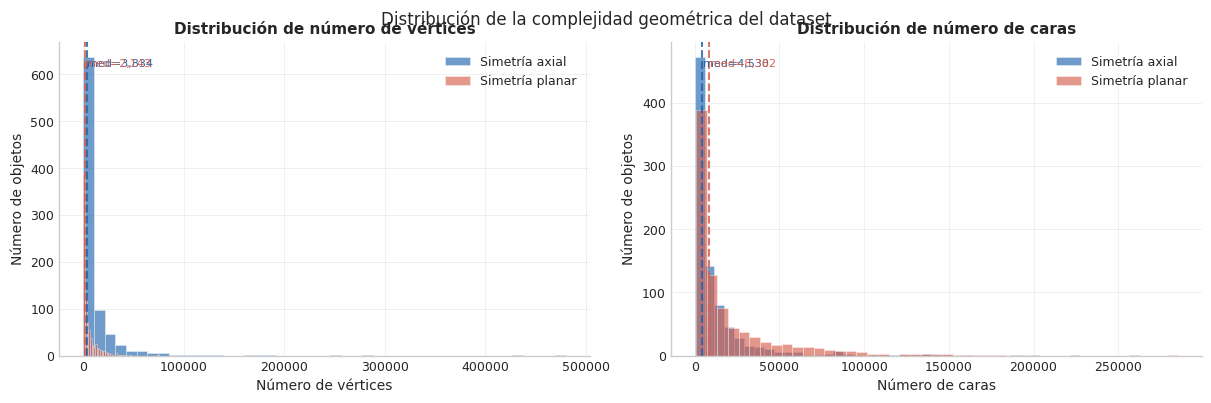

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

for ax, col, xlabel in zip(
        axes,
        ['vertex_count', 'face_count'],
        ['Número de vértices', 'Número de caras']):

    for sym_type, color, label in [
            ('axis_sym',  C_AXIS,  'Simetría axial'),
            ('plane_sym', C_PLANE, 'Simetría planar')]:
        data = df_all.loc[df_all['symmetry_type'] == sym_type, col]
        ax.hist(data, bins=45, alpha=0.65, color=color, label=label,
                edgecolor='white', linewidth=0.4)
        med = data.median()
        ax.axvline(med, color=color, lw=1.5, ls='--', alpha=0.85)
        ax.text(med * 1.04, ax.get_ylim()[1] * 0.92,
                f'med={med:,.0f}', color=color, fontsize=8)

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Número de objetos')
    ax.set_title(f'Distribución de {xlabel.lower()}')
    ax.legend(loc='upper right')

fig.suptitle('Distribución de la complejidad geométrica del dataset', y=1.02)
plt.savefig('fig_complejidad_hist.pdf', dpi=150)
plt.show()


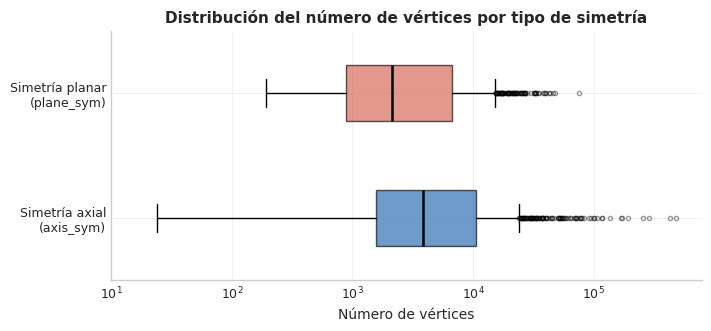

Top 5 objetos más complejos (axis_sym):
                       object_id  vertex_count  face_count
39ea99284138e5e835b3d63776480dcf        480092      201480
f97011a0bae2b4062d1c72b9dec4baa1        432280      221704
ec2c1338e2faae58adbcc9ee28cee4cb        287390      262048
4e54fc131882f2233c8d0fdfb1cc2535        255086      150908
9749404078fe4a8b6afaa22adc38077c        191096       91808

Top 5 objetos más complejos (plane_sym):
                       object_id  vertex_count  face_count
8843d862a7545d0d96db382b382d7132         75563      284996
693b8a150f9e844e50539bb73fa8aaff         47832      193066
 193fdf550fd5f12f446f92b52bbd82a         46235      180202
303555f1c5f4cb0a1082f2ea630bf69e         43594      172824
619b49bae27807fb1082f2ea630bf69e         42861      171072


In [34]:
fig, ax = plt.subplots(figsize=(7, 3.2))

data_axis  = df_axis ['vertex_count']
data_plane = df_plane['vertex_count']

bp = ax.boxplot(
    [data_axis, data_plane],
    tick_labels=['Simetría axial\n(axis_sym)', 'Simetría planar\n(plane_sym)'],
    vert=False, patch_artist=True, widths=0.45,
    flierprops=dict(marker='o', markersize=3, alpha=0.4, linestyle='none'),
    medianprops=dict(color='black', linewidth=1.8),
)
bp['boxes'][0].set(facecolor=C_AXIS,  alpha=0.65)
bp['boxes'][1].set(facecolor=C_PLANE, alpha=0.65)

ax.set_xlabel('Número de vértices')
ax.set_title('Distribución del número de vértices por tipo de simetría')
ax.set_xscale('log')
ax.set_xlim(left=10)

plt.savefig('fig_complejidad_boxplot.pdf', dpi=150)
plt.show()

print("Top 5 objetos más complejos (axis_sym):")
print(df_axis.nlargest(5,'vertex_count')[['object_id','vertex_count','face_count']].to_string(index=False))
print("\nTop 5 objetos más complejos (plane_sym):")
print(df_plane.nlargest(5,'vertex_count')[['object_id','vertex_count','face_count']].to_string(index=False))


## 6. Normalización de escala: ¿`axis_sym` y `plane_sym` son comparables?

El README documenta que los objetos están "normalizados a cubo unitario".
Medimos la diagonal del bounding box para verificarlo en ambos curated sets.


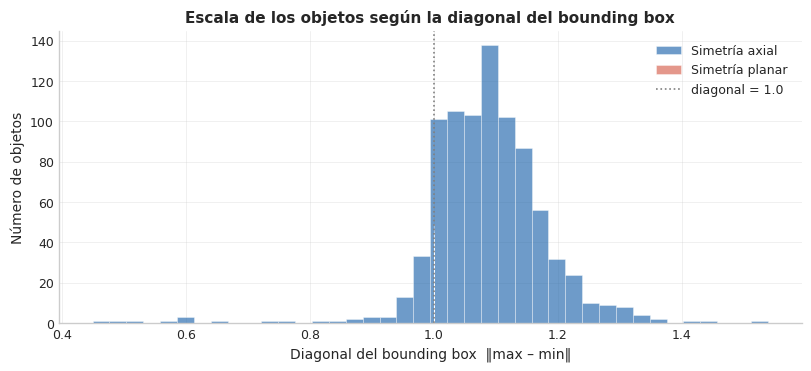

                  min    max    mean     std
symmetry_type                               
axis_sym       0.4486  1.539  1.0864  0.0962
plane_sym      1.0000  1.000  1.0000  0.0000

plane_sym: diagonal fija a 1.000 (std≈4e-7) en el 100 % de los objetos.
axis_sym : diagonal variable (std=0.096).  Outliers IQR [0.881, 1.286]: 31 / 850


In [35]:
fig, ax = plt.subplots(figsize=(8, 3.6))

for sym_type, color, label in [
        ('axis_sym',  C_AXIS,  'Simetría axial'),
        ('plane_sym', C_PLANE, 'Simetría planar')]:
    data = df_all.loc[df_all['symmetry_type'] == sym_type, 'bbox_diag']
    ax.hist(data, bins=40, alpha=0.65, color=color, label=label,
            edgecolor='white', linewidth=0.4)

ax.axvline(1.0, color='gray', lw=1.2, ls=':', label='diagonal = 1.0')
ax.set_xlabel('Diagonal del bounding box  ‖max – min‖')
ax.set_ylabel('Número de objetos')
ax.set_title('Escala de los objetos según la diagonal del bounding box')
ax.legend()

plt.savefig('fig_normalizacion.pdf', dpi=150)
plt.show()

print(df_all.groupby('symmetry_type')['bbox_diag'].agg(['min','max','mean','std']).round(4))

# Outliers en axis_sym por IQR
d = df_axis['bbox_diag']
q1, q3 = d.quantile([0.25, 0.75])
lo, hi = q1 - 1.5*(q3-q1), q3 + 1.5*(q3-q1)
outliers = df_axis[(d < lo) | (d > hi)]
print(f"\nplane_sym: diagonal fija a 1.000 (std≈4e-7) en el 100 % de los objetos.")
print(f"axis_sym : diagonal variable (std={d.std():.3f}).  "
      f"Outliers IQR [{lo:.3f}, {hi:.3f}]: {len(outliers)} / {len(df_axis)}")


## 7. Estructura de simetría — `plane_sym`

¿Cuántos planos de reflexión tiene cada objeto?
¿Sus normales están alineadas a los ejes canónicos X/Y/Z?


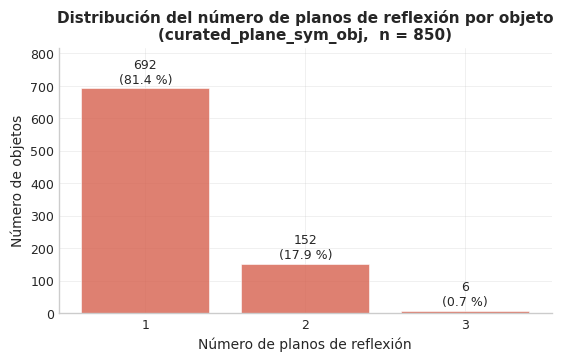

In [36]:
plane_count = df_plane['n_planes'].value_counts().sort_index()
total = plane_count.sum()

fig, ax = plt.subplots(figsize=(5.5, 3.5))
bars = ax.bar(plane_count.index.astype(str), plane_count.values,
              color=C_PLANE, alpha=0.80, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, plane_count.values):
    pct = 100 * val / total
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 8,
            f'{val}\n({pct:.1f} %)', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Número de planos de reflexión')
ax.set_ylabel('Número de objetos')
ax.set_title('Distribución del número de planos de reflexión por objeto\n(curated_plane_sym_obj,  n = 850)')
ax.set_ylim(top=plane_count.max() * 1.18)

plt.savefig('fig_n_planos.pdf', dpi=150)
plt.show()


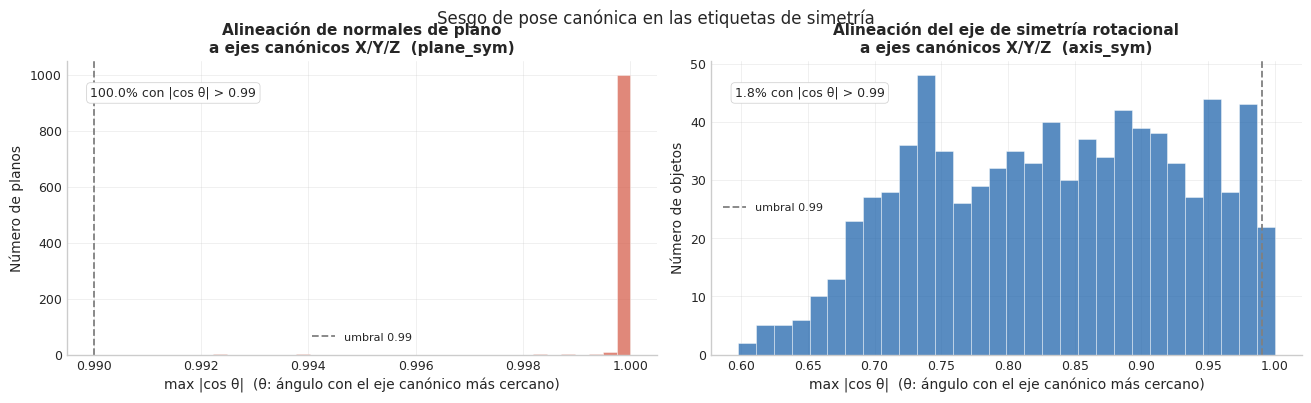

plane_sym — normales con |cos θ|>0.99 : 100.0%
axis_sym  — ejes    con |cos θ|>0.99 : 1.8%


In [37]:
def best_axis_alignment(normal):
    n = np.array(normal, dtype=float)
    norm = np.linalg.norm(n)
    if norm == 0: return np.nan
    return float(np.abs(np.eye(3) @ (n / norm)).max())

all_normals    = [n for norms in df_plane['normals'] for n in norms]
plane_align    = [best_axis_alignment(n) for n in all_normals]
axis_dirs      = np.array(list(df_axis['direction']))
ax_align       = [best_axis_alignment(d) for d in axis_dirs]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

# ── Panel izquierdo: normales de planos (plane_sym) ────────────────────────
ax = axes[0]
ax.hist(plane_align, bins=30, color=C_PLANE, alpha=0.75,
        edgecolor='white', linewidth=0.4)
ax.axvline(0.99, color='gray', lw=1.3, ls='--', label='umbral 0.99')
ax.set_xlabel('max |cos θ|  (θ: ángulo con el eje canónico más cercano)')
ax.set_ylabel('Número de planos')
ax.set_title('Alineación de normales de plano\na ejes canónicos X/Y/Z  (plane_sym)')
frac_p = np.mean(np.array(plane_align) > 0.99)
ax.text(0.04, 0.88, f'{frac_p:.1%} con |cos θ| > 0.99',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc'))
ax.legend(fontsize=8)

# ── Panel derecho: ejes de simetría (axis_sym) ─────────────────────────────
ax = axes[1]
ax.hist(ax_align, bins=30, color=C_AXIS, alpha=0.75,
        edgecolor='white', linewidth=0.4)
ax.axvline(0.99, color='gray', lw=1.3, ls='--', label='umbral 0.99')
ax.set_xlabel('max |cos θ|  (θ: ángulo con el eje canónico más cercano)')
ax.set_ylabel('Número de objetos')
ax.set_title('Alineación del eje de simetría rotacional\na ejes canónicos X/Y/Z  (axis_sym)')
frac_a = np.mean(np.array(ax_align) > 0.99)
ax.text(0.04, 0.88, f'{frac_a:.1%} con |cos θ| > 0.99',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc'))
ax.legend(fontsize=8)

fig.suptitle('Sesgo de pose canónica en las etiquetas de simetría', y=1.02)
plt.savefig('fig_alineacion_canonica.pdf', dpi=150)
plt.show()

print(f"plane_sym — normales con |cos θ|>0.99 : {frac_p:.1%}")
print(f"axis_sym  — ejes    con |cos θ|>0.99 : {frac_a:.1%}")


## 8. Estructura de simetría — `axis_sym`

Orientación del eje en la esfera unitaria y **orden rotacional** derivado de la
sección `angles` de las etiquetas (`n = round(360 / θ)`).


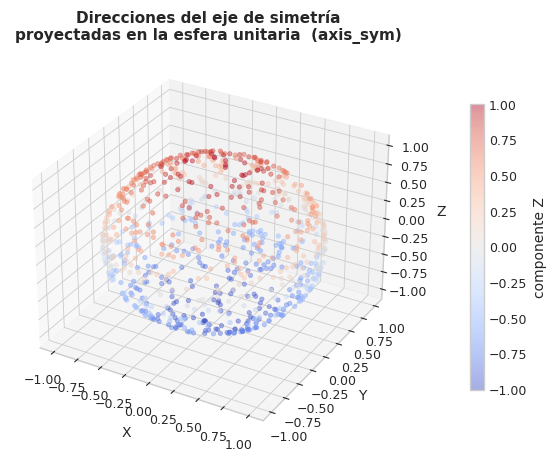

In [38]:
fig = plt.figure(figsize=(5.5, 5))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(axis_dirs[:, 0], axis_dirs[:, 1], axis_dirs[:, 2],
                s=10, alpha=0.45, c=axis_dirs[:, 2],
                cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xlabel('X', labelpad=4)
ax.set_ylabel('Y', labelpad=4)
ax.set_zlabel('Z', labelpad=4)
ax.set_title('Direcciones del eje de simetría\nproyectadas en la esfera unitaria  (axis_sym)')
plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.1, label='componente Z')

plt.savefig('fig_esfera_ejes.pdf', dpi=150)
plt.show()


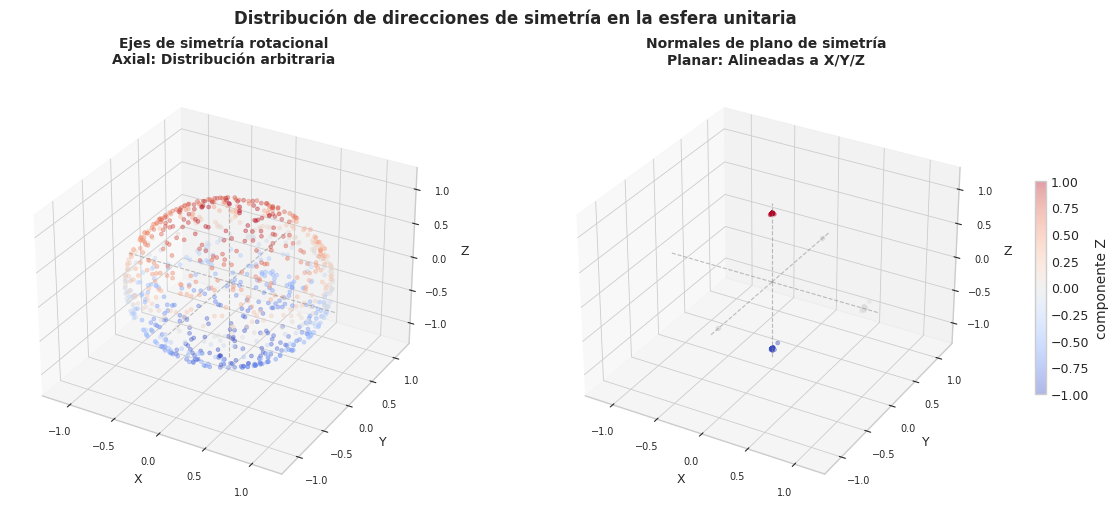

In [55]:
plane_normals = np.array([n for norms in df_plane['normals'] for n in norms])

fig = plt.figure(figsize=(12, 5))

datasets = [
    (axis_dirs,    C_AXIS,  'axis_sym',  'Ejes de simetría rotacional\nAxial: Distribución arbitraria'),
    (plane_normals, C_PLANE, 'plane_sym', 'Normales de plano de simetría\nPlanar: Alineadas a X/Y/Z'),
]

for i, (dirs, color, label, title) in enumerate(datasets):
    ax = fig.add_subplot(1, 2, i + 1, projection='3d')
    sc = ax.scatter(dirs[:, 0], dirs[:, 1], dirs[:, 2],
                    s=8, alpha=0.40, c=dirs[:, 2],
                    cmap='coolwarm', vmin=-1, vmax=1)
    # ejes canónicos de referencia
    for vec, name in [([1,0,0],'X'), ([0,1,0],'Y'), ([0,0,1],'Z')]:
        for sign in [1, -1]:
            v = [sign * x * 1.15 for x in vec]
            ax.plot([0, v[0]], [0, v[1]], [0, v[2]],
                    color='gray', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel('X', labelpad=2, fontsize=9)
    ax.set_ylabel('Y', labelpad=2, fontsize=9)
    ax.set_zlabel('Z', labelpad=2, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=8)
    ax.tick_params(labelsize=7)

plt.colorbar(sc, ax=fig.axes, shrink=0.5, pad=0.04, label='componente Z')
fig.suptitle('Distribución de direcciones de simetría en la esfera unitaria', fontsize=12, fontweight='bold')
plt.savefig('fig_esfera_comparativa.pdf', dpi=150, bbox_inches='tight')
plt.show()


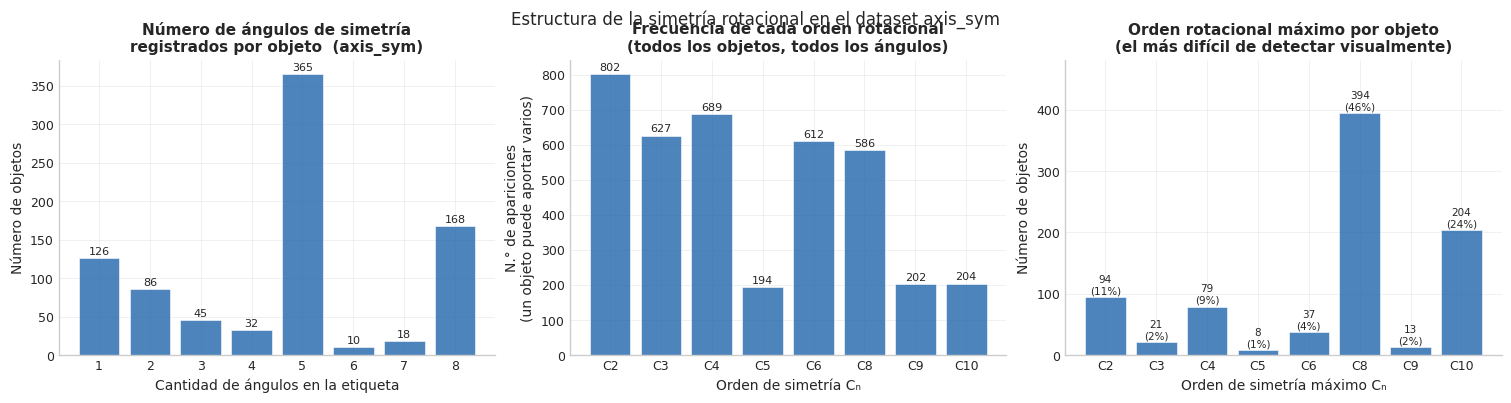

Distribución del orden rotacional máximo:
                    n_objetos
max_rotation_order           
2                          94
3                          21
4                          79
5                           8
6                          37
8                         394
9                          13
10                        204


In [ ]:
n_angles_counts   = df_axis['n_angles'].value_counts().sort_index()
all_orders        = sorted({int(o) for lst in df_axis['rotation_orders'] for o in lst})
order_counts      = pd.Series(
    [int(o) for lst in df_axis['rotation_orders'] for o in lst]
).value_counts().sort_index()
max_order_counts  = df_axis['max_rotation_order'].astype(int).value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

# ── Panel 1: n_angles ──────────────────────────────────────────────────────
ax = axes[0]
total1 = n_angles_counts.sum()
bars = ax.bar(n_angles_counts.index.astype(str), n_angles_counts.values,
              color=C_AXIS, alpha=0.80, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, n_angles_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2, str(val),
            ha='center', va='bottom', fontsize=8)
ax.set_xlabel('Cantidad de ángulos en la etiqueta')
ax.set_ylabel('Número de objetos')
ax.set_title('Número de ángulos de simetría\nregistrados por objeto  (axis_sym)')

# ── Panel 2: orden rotacional individual ──────────────────────────────────
ax = axes[1]
cn_labels = [f'C{n}' for n in order_counts.index]
bars = ax.bar(cn_labels, order_counts.values,
              color=C_AXIS, alpha=0.80, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, order_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5, str(val),
            ha='center', va='bottom', fontsize=8)
ax.set_xlabel('Orden de simetría Cₙ')
ax.set_ylabel('N.° de apariciones\n(un objeto puede aportar varios)')
ax.set_title('Frecuencia de cada orden rotacional\n(todos los objetos, todos los ángulos)')

# ── Panel 3: orden máximo por objeto ──────────────────────────────────────
ax = axes[2]
cn_labels_max = [f'C{n}' for n in max_order_counts.index]
bars = ax.bar(cn_labels_max, max_order_counts.values,
              color=C_AXIS, alpha=0.80, edgecolor='white', linewidth=0.5)
total3 = max_order_counts.sum()
for bar, val in zip(bars, max_order_counts.values):
    pct = 100 * val / total3
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2,
            f'{val}\n({pct:.0f}%)',
            ha='center', va='bottom', fontsize=7.5)
ax.set_xlabel('Orden de simetría máximo Cₙ')
ax.set_ylabel('Número de objetos')
ax.set_title('Orden rotacional máximo por objeto\n(el más difícil de detectar visualmente)')
ax.set_ylim(top=max_order_counts.max() * 1.22)

fig.suptitle('Estructura de la simetría rotacional en el dataset axis_sym', y=1.02)
plt.savefig('fig_ordenes_rotacionales.pdf', dpi=150)
plt.show()

print("Distribución del orden rotacional máximo:")
print(max_order_counts.rename('n_objetos').to_fra   me())


## 9. Relación entre complejidad de malla y estructura de simetría

¿Los objetos con mayor número de planos o mayor orden rotacional son también
geométricamente más complejos? Una correlación fuerte introduciría un confusor
en la evaluación de Molmo2.


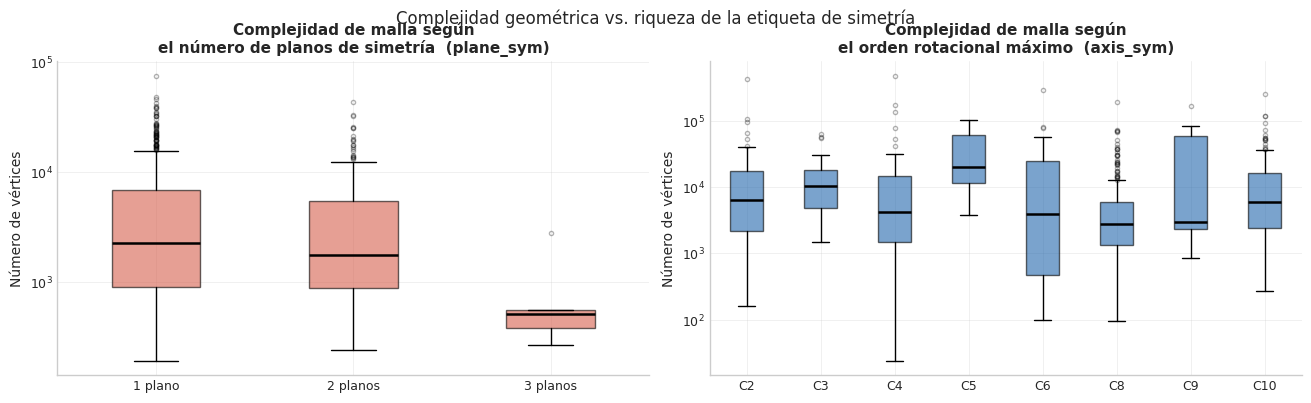

Correlación de Spearman — vertex_count vs. n_planes         : -0.054
Correlación de Spearman — vertex_count vs. max_rot_order    : 0.008


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

# ── Panel izquierdo: vertex_count por n_planes ────────────────────────────
ax = axes[0]
groups_p = sorted(df_plane['n_planes'].unique())
data_p   = [df_plane.loc[df_plane['n_planes'] == k, 'vertex_count'] for k in groups_p]
bp = ax.boxplot(data_p, tick_labels=[f'{k} plano{"s" if k>1 else ""}' for k in groups_p],
                patch_artist=True, widths=0.45,
                flierprops=dict(marker='o', markersize=3, alpha=0.3, linestyle='none'),
                medianprops=dict(color='black', lw=1.8))
for box in bp['boxes']:
    box.set(facecolor=C_PLANE, alpha=0.60)
ax.set_ylabel('Número de vértices')
ax.set_title('Complejidad de malla según\nel número de planos de simetría  (plane_sym)')
ax.set_yscale('log')

# ── Panel derecho: vertex_count por max_rotation_order ────────────────────
ax = axes[1]
groups_a = sorted(df_axis['max_rotation_order'].unique())
data_a   = [df_axis.loc[df_axis['max_rotation_order'] == k, 'vertex_count'] for k in groups_a]
bp = ax.boxplot(data_a,
                tick_labels=[f'C{int(k)}' for k in groups_a],
                patch_artist=True, widths=0.45,
                flierprops=dict(marker='o', markersize=3, alpha=0.3, linestyle='none'),
                medianprops=dict(color='black', lw=1.8))
for box in bp['boxes']:
    box.set(facecolor=C_AXIS, alpha=0.60)
ax.set_ylabel('Número de vértices')
ax.set_title('Complejidad de malla según\nel orden rotacional máximo  (axis_sym)')
ax.set_yscale('log')

fig.suptitle('Complejidad geométrica vs. riqueza de la etiqueta de simetría', y=1.02)
plt.savefig('fig_complejidad_vs_simetria.pdf', dpi=150)
plt.show()

rho_p = df_plane[['vertex_count','n_planes']].corr(method='spearman').iloc[0,1]
rho_a = df_axis[['vertex_count','max_rotation_order']].corr(method='spearman').iloc[0,1]
print(f"Correlación de Spearman — vertex_count vs. n_planes         : {rho_p:.3f}")
print(f"Correlación de Spearman — vertex_count vs. max_rot_order    : {rho_a:.3f}")


## 10. Resumen ejecutivo

*(Los números de esta sección corresponden a la ejecución actual del notebook.)*

- **Tamaño e integridad**: 850 objetos `axis_sym` + 850 `plane_sym`, todos con par OBJ/TXT
  completo, **0 IDs duplicados** entre los dos curated sets.
- **Complejidad de malla**: distribución muy sesgada a la derecha en ambos datasets.
  `axis_sym` presenta mayor mediana (≈3 835 vértices) y cola más extrema (hasta 480 092) que
  `plane_sym` (mediana ≈2 143; máximo ≈75 563).
- **Normalización inconsistente**: `plane_sym` tiene `bbox_diag` fija a 1.000 (std ≈4e-7);
  `axis_sym` varía entre 0.449 y 1.539 (media 1.086, std 0.096). Los dos sets no comparten la
  misma convención de escala — comparar distancias absolutas entre ellos requiere renormalización.
- **Sesgo de pose canónica**: el 100% de las normales de plano están alineadas a un eje
  canónico (X dominante con 78.5%), frente al 1.8% de los ejes de simetría axial. Los ejes de
  `axis_sym` se distribuyen arbitrariamente sobre la esfera unitaria: es el benchmark más
  exigente y honesto para evaluar si Molmo2 razona sobre la geometría real.
- **Orden rotacional**: el grupo {2,3,4,6,8} es el más frecuente (42.4%). El orden máximo por
  objeto está dominado por C₈ (46%) y C₁₀ (24%). El orden C₇ está completamente ausente.
- **Correlación complejidad–simetría**: Spearman ≈ -0.05 (plane_sym) y ≈ 0.01 (axis_sym) —
  esencialmente nula. La dificultad geométrica y la riqueza de la etiqueta son independientes.


## 11. ECDF en escala logarítmica y ratio vértices/caras

La escala logarítmica revela la forma real de las distribuciones de complejidad.
El scatter log–log de vértices vs. caras informa sobre el tipo de malla predominante
(triangulada ≈ v/f = 0.5; mallas quad ≈ v/f = 1.0).


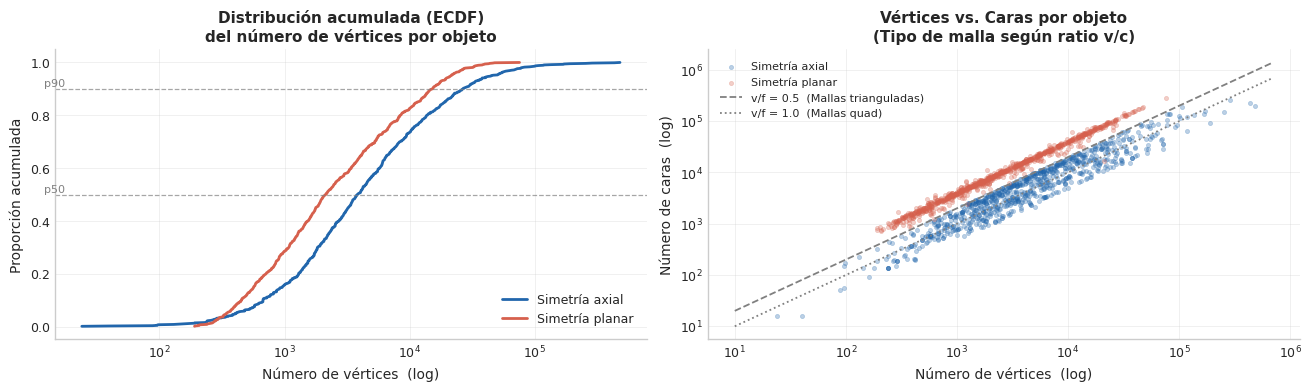

Ratio vértices/caras  (v/f)  —  triángulos ≈ 0.5,  quads ≈ 1.0:
               count   mean    std    min    25%    50%    75%    max
symmetry_type                                                        
axis_sym       850.0  0.978  0.442  0.497  0.603  0.854  1.239  2.570
plane_sym      850.0  0.263  0.050  0.171  0.246  0.253  0.268  1.253


In [53]:
def ecdf_xy(data):
    x = np.sort(np.asarray(data, dtype=float))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

# ── ECDF log-x ────────────────────────────────────────────────────────────
ax = axes[0]
for sym_type, color, label in [
        ('axis_sym',  C_AXIS,  'Simetría axial'),
        ('plane_sym', C_PLANE, 'Simetría planar')]:
    data = df_all.loc[df_all['symmetry_type'] == sym_type, 'vertex_count']
    x, y = ecdf_xy(data)
    ax.plot(x, y, color=color, label=label, lw=2)

ax.set_xscale('log')
for q, label in [(0.50, 'p50'), (0.90, 'p90')]:
    ax.axhline(q, color='gray', lw=0.9, ls='--', alpha=0.7)
    ax.text(12, q + 0.01, label, fontsize=8, color='gray')
ax.set_xlabel('Número de vértices  (log)')
ax.set_ylabel('Proporción acumulada')
ax.set_title('Distribución acumulada (ECDF)\ndel número de vértices por objeto')
ax.legend()

# ── Scatter log-log vértices vs. caras ────────────────────────────────────
ax = axes[1]
for sym_type, color, label in [
        ('axis_sym',  C_AXIS,  'Simetría axial'),
        ('plane_sym', C_PLANE, 'Simetría planar')]:
    sub = df_all[df_all['symmetry_type'] == sym_type]
    ax.scatter(sub['vertex_count'], sub['face_count'],
               s=9, alpha=0.30, color=color, label=label, rasterized=True)

xlims = np.array([10, 7e5])
ax.plot(xlims, xlims * 2.0, color='gray', lw=1.3, ls='--',
        label='v/f = 0.5  (Mallas trianguladas)')
ax.plot(xlims, xlims * 1.0, color='gray', lw=1.3, ls=':',
        label='v/f = 1.0  (Mallas quad)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Número de vértices  (log)')
ax.set_ylabel('Número de caras  (log)')
ax.set_title('Vértices vs. Caras por objeto\n(Tipo de malla según ratio v/c)')
ax.legend(fontsize=8)

fig.suptitle('', y=1.02)
plt.savefig('fig_ecdf_vf.pdf', dpi=150)
plt.show()

df_all['vf_ratio'] = df_all['vertex_count'] / df_all['face_count']
print("Ratio vértices/caras  (v/f)  —  triángulos ≈ 0.5,  quads ≈ 1.0:")
print(df_all.groupby('symmetry_type')['vf_ratio'].describe().round(3))


## 12. Elongación del bounding box y correlación con la simetría

**Hipótesis del atajo geométrico**: si el eje de simetría de `axis_sym` tiende
a alinearse con la dimensión más larga del objeto (ej. una botella), o si la normal
de `plane_sym` apunta hacia la dimensión más corta, un modelo podría detectar la
simetría simplemente por la forma global sin razonar sobre la geometría real.


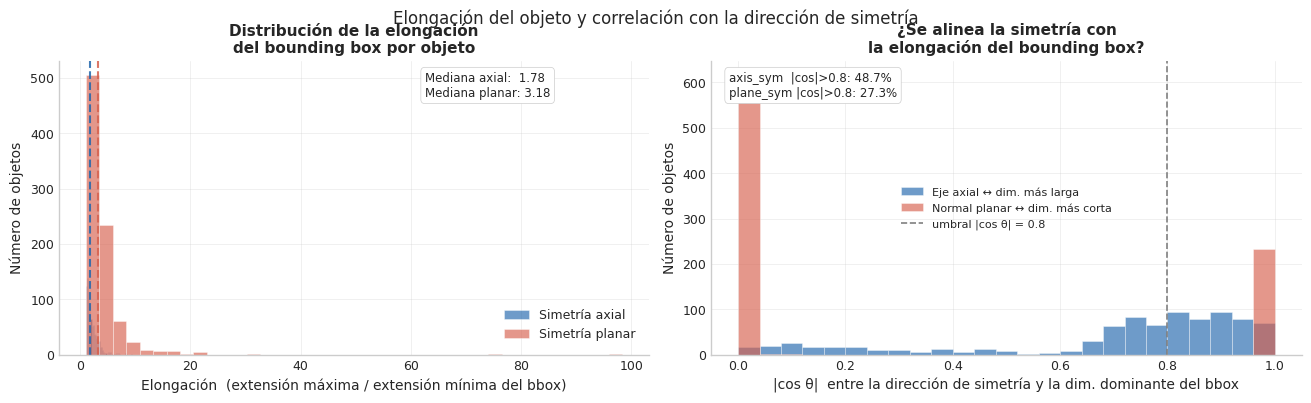

Fracción axis_sym  con eje ≈ dimensión más larga   (|cos|>0.8): 48.7%
Fracción plane_sym con normal ≈ dimensión más corta (|cos|>0.8): 27.3%


In [42]:
extents_axis  = np.array([list(e) for e in df_axis ['bbox_extent']])
extents_plane = np.array([list(e) for e in df_plane['bbox_extent']])

elong_axis  = extents_axis .max(1) / np.clip(extents_axis .min(1), 1e-9, None)
elong_plane = extents_plane.max(1) / np.clip(extents_plane.min(1), 1e-9, None)

# Alineación del eje de simetría con la dimensión más larga
longest_idx   = extents_axis.argmax(axis=1)
can_longest   = np.eye(3)[longest_idx]
dirs_unit     = axis_dirs / np.clip(np.linalg.norm(axis_dirs, axis=1, keepdims=True), 1e-9, None)
align_ax_long = np.abs((dirs_unit * can_longest).sum(axis=1))

# Alineación de la normal del plano con la dimensión más corta
thinnest_idx    = extents_plane.argmin(axis=1)
can_thinnest    = np.eye(3)[thinnest_idx]
norms_first     = np.array([row[0] for row in df_plane['normals']])
norms_unit      = norms_first / np.clip(np.linalg.norm(norms_first, axis=1, keepdims=True), 1e-9, None)
align_pl_thin   = np.abs((norms_unit * can_thinnest).sum(axis=1))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

# ── Panel izquierdo: distribución de elongación ───────────────────────────
ax = axes[0]
ax.hist(elong_axis,  bins=40, alpha=0.65, color=C_AXIS,  label='Simetría axial',
        edgecolor='white', linewidth=0.4)
ax.hist(elong_plane, bins=40, alpha=0.65, color=C_PLANE, label='Simetría planar',
        edgecolor='white', linewidth=0.4)
for data, color in [(elong_axis, C_AXIS), (elong_plane, C_PLANE)]:
    med = np.median(data)
    ax.axvline(med, color=color, lw=1.5, ls='--', alpha=0.85)
ax.set_xlabel('Elongación  (extensión máxima / extensión mínima del bbox)')
ax.set_ylabel('Número de objetos')
ax.set_title('Distribución de la elongación\ndel bounding box por objeto')
ax.legend()
ax.text(0.62, 0.88,
        f'Mediana axial:  {np.median(elong_axis):.2f}\n'
        f'Mediana planar: {np.median(elong_plane):.2f}',
        transform=ax.transAxes, fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#cccccc'))

# ── Panel derecho: alineación con la dimensión dominante ─────────────────
ax = axes[1]
bins = np.linspace(0, 1, 26)
ax.hist(align_ax_long, bins=bins, alpha=0.65, color=C_AXIS,
        label='Eje axial ↔ dim. más larga',    edgecolor='white', linewidth=0.4)
ax.hist(align_pl_thin, bins=bins, alpha=0.65, color=C_PLANE,
        label='Normal planar ↔ dim. más corta', edgecolor='white', linewidth=0.4)
ax.axvline(0.8, color='gray', lw=1.2, ls='--', label='umbral |cos θ| = 0.8')
ax.set_xlabel('|cos θ|  entre la dirección de simetría y la dim. dominante del bbox')
ax.set_ylabel('Número de objetos')
ax.set_title('¿Se alinea la simetría con\nla elongación del bounding box?')
ax.legend(fontsize=8)
frac_al = (align_ax_long > 0.8).mean()
frac_pl = (align_pl_thin > 0.8).mean()
ax.text(0.03, 0.88,
        f'axis_sym  |cos|>0.8: {frac_al:.1%}\nplane_sym |cos|>0.8: {frac_pl:.1%}',
        transform=ax.transAxes, fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#cccccc'))

fig.suptitle('Elongación del objeto y correlación con la dirección de simetría', y=1.02)
plt.savefig('fig_elongacion.pdf', dpi=150)
plt.show()

print(f"Fracción axis_sym  con eje ≈ dimensión más larga   (|cos|>0.8): {frac_al:.1%}")
print(f"Fracción plane_sym con normal ≈ dimensión más corta (|cos|>0.8): {frac_pl:.1%}")


## 13. ¿A qué eje canónico apuntan los planos de reflexión?

Ya que el 100% de las normales están alineadas a un eje canónico, exploramos
**cuál** eje (X, Y o Z) y qué combinaciones aparecen en objetos con 2 o 3 planos.


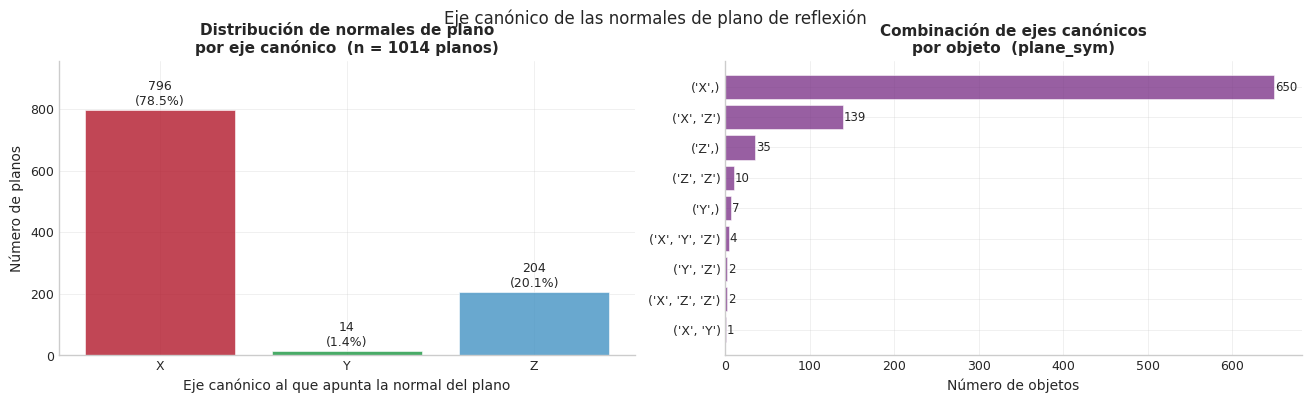

Distribución global de normales por eje canónico:
      n_planos
axis          
X          796
Y           14
Z          204

Top 10 combinaciones de ejes por objeto:
axis
(X,)         650
(X, Z)       139
(Z,)          35
(Z, Z)        10
(Y,)           7
(X, Y, Z)      4
(Y, Z)         2
(X, Z, Z)      2
(X, Y)         1
Name: count, dtype: int64


In [43]:
def canonical_axis_name(normal):
    n = np.abs(np.array(normal, dtype=float))
    norm = np.linalg.norm(n)
    if norm == 0: return '?'
    return ['X', 'Y', 'Z'][int((n / norm).argmax())]

plane_rows = []
for _, row in df_plane.iterrows():
    for normal in row['normals']:
        plane_rows.append({'object_id': row['object_id'],
                           'n_planes' : row['n_planes'],
                           'axis'     : canonical_axis_name(normal)})
df_pnormals = pd.DataFrame(plane_rows)

axis_global  = df_pnormals['axis'].value_counts().sort_index()
total_planes = len(df_pnormals)

combos = (df_pnormals
          .groupby('object_id')['axis']
          .apply(lambda s: tuple(sorted(s)))
          .value_counts())

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

# ── Panel izquierdo: distribución por eje canónico ────────────────────────
ax = axes[0]
colors_xyz = [C_X, C_Y, C_Z]
bars = ax.bar(axis_global.index, axis_global.values,
              color=colors_xyz, alpha=0.80, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, axis_global.values):
    pct = 100 * val / total_planes
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 8,
            f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Eje canónico al que apunta la normal del plano')
ax.set_ylabel('Número de planos')
ax.set_title(f'Distribución de normales de plano\npor eje canónico  (n = {total_planes} planos)')
ax.set_ylim(top=axis_global.max() * 1.20)

# ── Panel derecho: combinaciones por objeto ───────────────────────────────
ax = axes[1]
labels_c  = [str(c) for c in combos.index]
heights_c = combos.values
y_pos = range(len(labels_c))
ax.barh(list(y_pos)[::-1], heights_c, color=C_PURPLE, alpha=0.75,
        edgecolor='white', linewidth=0.5)
ax.set_yticks(list(y_pos)[::-1])
ax.set_yticklabels(labels_c, fontsize=9)
ax.set_xlabel('Número de objetos')
ax.set_title('Combinación de ejes canónicos\npor objeto  (plane_sym)')
for i, v in enumerate(heights_c):
    ax.text(v + 1, len(heights_c) - 1 - i, str(v), va='center', fontsize=8.5)

fig.suptitle('Eje canónico de las normales de plano de reflexión', y=1.02)
plt.savefig('fig_ejes_canonicos_planos.pdf', dpi=150)
plt.show()

print("Distribución global de normales por eje canónico:")
print(axis_global.rename('n_planos').to_frame())
print("\nTop 10 combinaciones de ejes por objeto:")
print(combos.head(10))


## 14. Co-ocurrencia de órdenes rotacionales

Si un objeto tiene simetría C₈ (rotación de 45°), también es necesariamente
simétrico bajo C₄ (90°) y C₂ (180°) — divisores del generador.
El heatmap revela esta estructura de subgrupos en los datos.


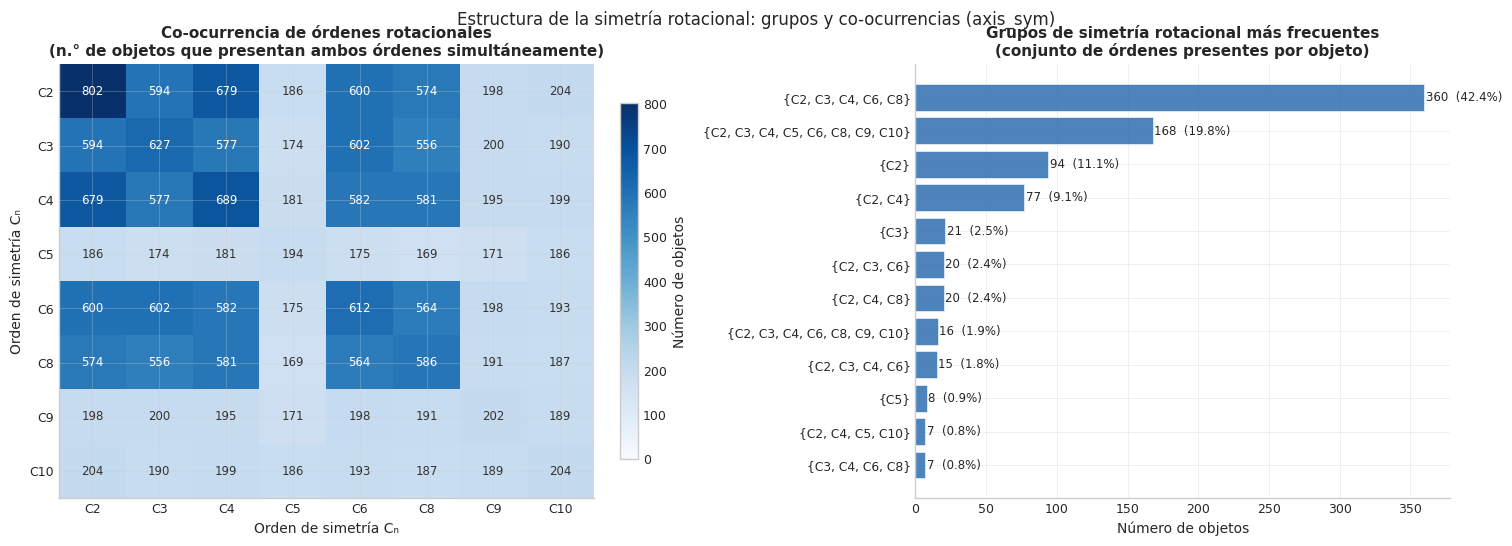

In [44]:
ALL_ORDERS = [2, 3, 4, 5, 6, 8, 9, 10]
idx_map    = {o: i for i, o in enumerate(ALL_ORDERS)}
n          = len(ALL_ORDERS)

cooc = np.zeros((n, n), dtype=int)
for orders in df_axis['rotation_orders']:
    unique = {int(round(o)) for o in orders if int(round(o)) in idx_map}
    for o1 in unique:
        for o2 in unique:
            cooc[idx_map[o1], idx_map[o2]] += 1

combo_freq = (df_axis['rotation_orders']
              .apply(lambda lst: tuple(sorted({int(round(o)) for o in lst})))
              .value_counts()
              .head(12))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

# ── Heatmap ───────────────────────────────────────────────────────────────
ax = axes[0]
im = ax.imshow(cooc, cmap='Blues', vmin=0, aspect='auto')
cn_ticks = [f'C{o}' for o in ALL_ORDERS]
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(cn_ticks, fontsize=9)
ax.set_yticklabels(cn_ticks, fontsize=9)
ax.set_xlabel('Orden de simetría Cₙ')
ax.set_ylabel('Orden de simetría Cₙ')
ax.set_title('Co-ocurrencia de órdenes rotacionales\n'
             '(n.° de objetos que presentan ambos órdenes simultáneamente)')
thresh = cooc.max() * 0.55
for i in range(n):
    for j in range(n):
        ax.text(j, i, str(cooc[i, j]), ha='center', va='center', fontsize=8.5,
                color='white' if cooc[i, j] > thresh else '#333333')
plt.colorbar(im, ax=ax, shrink=0.82, label='Número de objetos')

# ── Barras de combinaciones más frecuentes ────────────────────────────────
ax = axes[1]
labels_f  = ['{' + ', '.join(f'C{o}' for o in c) + '}' for c in combo_freq.index]
heights_f = combo_freq.values
y_pos = range(len(labels_f))
ax.barh(list(y_pos)[::-1], heights_f, color=C_AXIS, alpha=0.80,
        edgecolor='white', linewidth=0.5)
ax.set_yticks(list(y_pos)[::-1])
ax.set_yticklabels(labels_f, fontsize=8.8)
ax.set_xlabel('Número de objetos')
ax.set_title('Grupos de simetría rotacional más frecuentes\n'
             '(conjunto de órdenes presentes por objeto)')
total_combo = len(df_axis)
for i, v in enumerate(heights_f):
    pct = 100 * v / total_combo
    ax.text(v + 1, len(heights_f) - 1 - i, f'{v}  ({pct:.1f}%)',
            va='center', fontsize=8.5)

fig.suptitle('Estructura de la simetría rotacional: grupos y co-ocurrencias (axis_sym)', y=1.02)
plt.savefig('fig_coocurrencia_ordenes.pdf', dpi=150)
plt.show()


## 15. Origen de los planos de simetría

En un objeto correctamente centrado en el origen, cada plano de simetría debería
pasar por (0, 0, 0). La distancia ‖origin‖ cuantifica el descentrado.


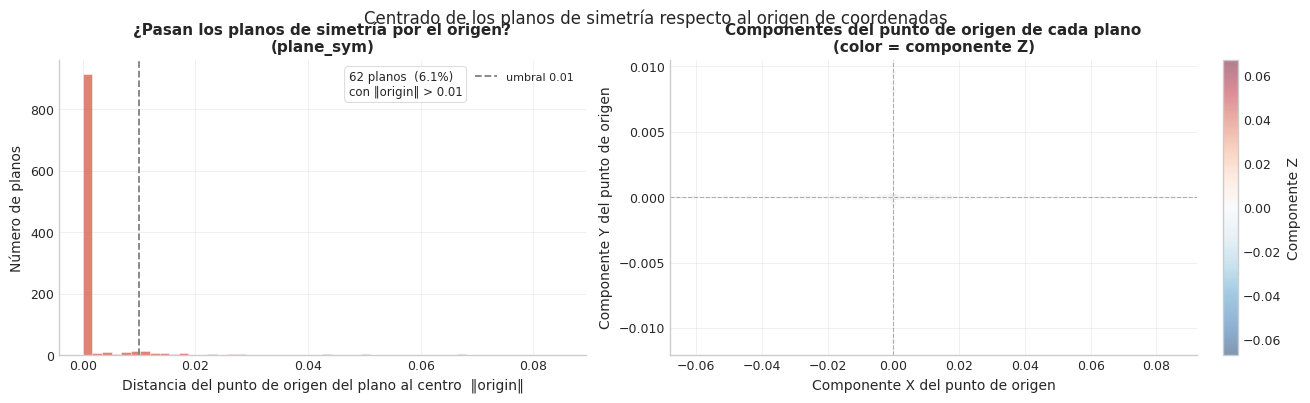

Estadísticas de ‖origin‖:
count    1014.000000
mean        0.001676
std         0.006989
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.085115
Name: origin_norm, dtype: float64

Planos con ‖origin‖ > 0.01: 62 / 1014
Planos con ‖origin‖ > 0.05: 6 / 1014


In [45]:
orig_rows = []
for txt_path in sorted(PLANE_DIR.glob('*.txt')):
    for p in parse_plane_label(txt_path)['planes']:
        o = np.array(p['origin'])
        orig_rows.append({'object_id': txt_path.stem,
                          'origin_norm': float(np.linalg.norm(o)),
                          'ox': float(o[0]), 'oy': float(o[1]), 'oz': float(o[2])})
df_orig = pd.DataFrame(orig_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

# ── Histograma de ‖origin‖ ────────────────────────────────────────────────
ax = axes[0]
ax.hist(df_orig['origin_norm'], bins=50, color=C_PLANE, alpha=0.78,
        edgecolor='white', linewidth=0.4)
ax.axvline(0.01, color='gray', lw=1.3, ls='--', label='umbral 0.01')
n_above = (df_orig['origin_norm'] > 0.01).sum()
ax.text(0.55, 0.88,
        f'{n_above} planos  ({100*n_above/len(df_orig):.1f}%)\ncon ‖origin‖ > 0.01',
        transform=ax.transAxes, fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#cccccc'))
ax.set_xlabel('Distancia del punto de origen del plano al centro  ‖origin‖')
ax.set_ylabel('Número de planos')
ax.set_title('¿Pasan los planos de simetría por el origen?\n(plane_sym)')
ax.legend(fontsize=8)

# ── Scatter de componentes del origen ────────────────────────────────────
ax = axes[1]
sc = ax.scatter(df_orig['ox'], df_orig['oy'],
                s=12, alpha=0.50,
                c=df_orig['oz'], cmap='RdBu_r',
                vmin=-df_orig['oz'].abs().max(),
                vmax= df_orig['oz'].abs().max())
ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.axvline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel('Componente X del punto de origen')
ax.set_ylabel('Componente Y del punto de origen')
ax.set_title('Componentes del punto de origen de cada plano\n(color = componente Z)')
plt.colorbar(sc, ax=ax, label='Componente Z')

fig.suptitle('Centrado de los planos de simetría respecto al origen de coordenadas', y=1.02)
plt.savefig('fig_origen_planos.pdf', dpi=150)
plt.show()

print("Estadísticas de ‖origin‖:")
print(df_orig['origin_norm'].describe().round(6))
print(f"\nPlanos con ‖origin‖ > 0.01: {n_above} / {len(df_orig)}")
print(f"Planos con ‖origin‖ > 0.05: {(df_orig['origin_norm']>0.05).sum()} / {len(df_orig)}")


## Addendum al Resumen ejecutivo — secciones 11–15

- **Tipo de malla distinto entre datasets** (Sec. 11): ratio v/f mediana de 0.85 en
  `axis_sym` (mallas tipo quad) vs. 0.25 en `plane_sym` (altamente trianguladas). Los dos
  curated sets difieren no solo en escala sino en representación de malla.
- **El eje de simetría no predice la elongación** (Sec. 12): solo el 48.7% de los objetos
  axiales tienen su eje alineado (|cos θ|>0.8) con la dimensión más larga del bbox. La
  simetría planar tampoco sigue la dimensión más delgada (27.3%). Un modelo no puede
  resolver el problema simplemente detectando la forma global del objeto.
- **Las normales se concentran en el eje X** (Sec. 13): 78.5% de todos los planos tienen
  normal en X, 20.1% en Z, solo 1.4% en Y. Para objetos con 2 planos, el patrón dominante
  es (X, Z) en 139 de 152 casos. Esta asimetría no está documentada en el curado.
- **Estructura de subgrupos en los órdenes rotacionales** (Sec. 14): la combinación más
  frecuente es {C₂, C₃, C₄, C₆, C₈} (42.4% de los objetos), consecuencia de que C₈
  implica C₄ y C₂ como subgrupos. El heatmap muestra la jerarquía de divisibilidad.
- **Los planos pasan por el origen** (Sec. 15): mediana de ‖origin‖ = 0.0; solo 62/1014
  planos (6.1%) tienen descentrado > 0.01. El centrado en el origen es consistente.
